In [1]:
import sqlalchemy
import matplotlib.pyplot as plt
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

load_dotenv()

DB_HOST = os.getenv("SUPABASE_HOST")
DB_DB = os.getenv("SUPABASE_DB")
DB_USER = os.getenv("SUPABASE_USER")
DB_PASSWORD = quote_plus(os.getenv("SUPABASE_PASSWORD"))
DB_PORT = os.getenv("SUPABASE_PORT")

engine = sqlalchemy.create_engine(
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_DB}",
    connect_args={"sslmode": "require"},
    pool_pre_ping=True
)

print("✅ Fresh connection created")

✅ Fresh connection created


NameError: name 'df' is not defined

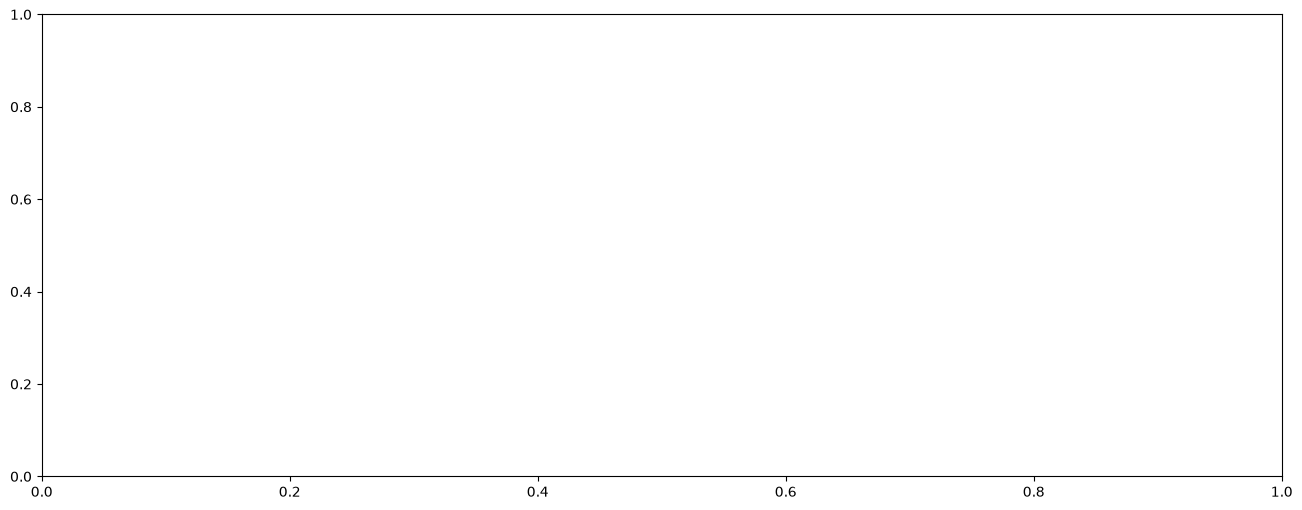

In [2]:
fig, ax = plt.subplots(figsize=(16, 6))

colors = {'Hathnikund Barrage': '#ff6b9d', 'Fatehgarh': '#7ecba1', 'Kalanaur': '#60a5fa'}

for station in df['station'].unique():
    station_data = df[df['station'] == station].sort_values('reading_time')
    ax.plot(station_data['reading_time'], station_data['water_level'], 
            label=station, color=colors[station], linewidth=1.5)

ax.set_title('90-Day Water Level History — Yamuna (Hathnikund → Fatehgarh → Kalanaur)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_sql('SELECT * FROM river_levels ORDER BY reading_time ASC', engine)
print(f"Total records: {len(df)}")
print(f"Date range: {df['reading_time'].min()} to {df['reading_time'].max()}")

fig, ax = plt.subplots(figsize=(16, 6))

colors = {'Hathnikund Barrage': '#ff6b9d', 'Fatehgarh': '#7ecba1', 'Kalanaur': '#60a5fa'}

for station in df['station'].unique():
    station_data = df[df['station'] == station].sort_values('reading_time')
    ax.plot(station_data['reading_time'], station_data['water_level'], 
            label=station, color=colors[station], linewidth=1)

ax.set_title('Full Year Water Level History — Yamuna', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df['reading_time'] = pd.to_datetime(df['reading_time'])

# Zoom into August-September 2025
mask = (df['reading_time'] >= '2025-08-01') & (df['reading_time'] <= '2025-09-30')
zoom_df = df[mask]

fig, ax = plt.subplots(figsize=(16, 6))

for station in zoom_df['station'].unique():
    station_data = zoom_df[zoom_df['station'] == station].sort_values('reading_time')
    ax.plot(station_data['reading_time'], station_data['water_level'], 
            label=station, color=colors[station], linewidth=1.5, marker='o', markersize=2)

ax.set_title('Zoomed: August-September 2025 (Monsoon Peak)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Focus on Hathnikund Barrage for now — single station forecasting
station_df = df[df['station'] == 'Hathnikund Barrage'].sort_values('reading_time').copy()
station_df = station_df[['reading_time', 'water_level']].dropna()
station_df = station_df.drop_duplicates(subset='reading_time')

print(f"Total clean records: {len(station_df)}")
print(station_df.head())
print(station_df.tail())

In [ ]:
# Scale data between 0-1, which LSTMs need
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(station_df[['water_level']])

# Create sequences: use past 24 hours to predict next hour
def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, lookback=24)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split into train/test - last 10% for testing
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for LSTM: [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

In [ ]:
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

In [ ]:
predictions = model.predict(X_test)

# Convert back to real water level values (undo scaling)
predictions_actual = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_test_actual, label='Actual Water Level', color='#60a5fa', linewidth=2)
ax.plot(predictions_actual, label='Predicted Water Level', color='#ff6b9d', linewidth=2, linestyle='--')
ax.set_title('Nadi LSTM — Predicted vs Actual Water Level (Hathnikund Barrage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Steps (hours)')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import os
os.makedirs("models", exist_ok=True)
model.save("models/nadi_lstm.keras")
print("✅ Model saved to models/nadi_lstm.keras")